In [ ]:
import csv
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
nodes = pd.read_csv(
    "/Users/yimengliu/Documents/Erdos_Institute/mgp/summer26-math-genealogy/data/processed/version2_new_dataset_fitted.csv"
)

In [3]:
nodes.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 338532 entries, 0 to 338531
Data columns (total 13 columns):
 #   Column                         Non-Null Count   Dtype  
---  ------                         --------------   -----  
 0   id                             338532 non-null  int64  
 1   name                           338526 non-null  object 
 2   thesis                         307399 non-null  object 
 3   school                         276167 non-null  object 
 4   country                        322986 non-null  object 
 5   year                           277237 non-null  float64
 6   advisors                       338532 non-null  object 
 7   students                       338532 non-null  object 
 8   subject_code                   280203 non-null  float64
 9   subject_name                   280203 non-null  object 
 10  predicted_subject_code         130825 non-null  float64
 11  subject_prediction_confidence  136040 non-null  float64
 12  subject_prediction_vector     

In [ ]:
codes=np.sort(nodes.subject_code.dropna().unique())
print(codes)

[ 0.  1.  3.  5.  6.  8. 11. 12. 13. 14. 15. 16. 17. 18. 19. 20. 22. 26.
 28. 30. 31. 32. 33. 34. 35. 37. 39. 40. 41. 42. 43. 44. 45. 46. 47. 49.
 51. 52. 53. 54. 55. 57. 58. 60. 62. 65. 68. 70. 74. 76. 78. 80. 81. 82.
 83. 85. 86. 90. 91. 92. 93. 94. 97.]


## 1. predict for pure math

In [ ]:
#Take data from year between 1900 and 2024
years = np.arange(1900, 2025)

valid_pure = nodes[
    (nodes["subject_code"].notna()) &
    (nodes["subject_code"]<61) &
    (nodes["year"].between(1900, 2026))
].copy()

valid_pure["year"] = valid_pure["year"].astype(int)

codes_pure = np.sort(valid_pure["subject_code"].unique())

counts = pd.crosstab(
    valid_pure["subject_code"],
    valid_pure["year"]
).reindex(index=codes_pure, columns=years, fill_value=0)

year_totals = counts.sum(axis=0).replace(0, np.nan)

share = counts.div(year_totals, axis=1) * 100


In [10]:
counts

year,1900,1901,1902,1903,1904,1905,1906,1907,1908,1909,...,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024
subject_code,,,,,,,,,,,,,,,,,,,,,
0.0,0,1,0,0,0,1,0,0,0,0,...,29,43,32,36,29,27,23,21,14,11
1.0,1,1,0,2,0,1,0,0,1,0,...,7,5,4,4,4,1,5,0,0,2
3.0,0,1,1,1,1,0,0,0,2,0,...,90,84,113,99,94,73,70,72,65,74
5.0,0,0,1,0,0,0,0,0,0,1,...,211,185,197,224,197,169,187,159,151,145
6.0,0,0,0,0,0,0,0,1,0,0,...,18,13,10,17,8,9,10,5,3,10
8.0,0,0,0,0,0,0,0,0,0,0,...,10,9,10,6,10,11,8,5,3,2
11.0,3,2,1,2,0,1,2,2,1,1,...,206,210,194,218,214,181,196,182,166,143
12.0,1,0,0,0,0,0,0,0,0,0,...,9,4,4,2,5,7,4,9,3,7
13.0,0,0,0,0,0,0,0,0,0,0,...,57,39,47,52,46,49,42,41,35,33


In [11]:
import statsmodels as sm

In [12]:
print(sm.__version__)

0.14.5


In [13]:
from statsmodels.tsa.api import SimpleExpSmoothing

### 1.1 Forcast for number of students in a given subject

In [17]:
counts.info()

<class 'pandas.core.frame.DataFrame'>
Index: 44 entries, 0.0 to 60.0
Columns: 125 entries, 1900 to 2024
dtypes: int64(125)
memory usage: 43.3 KB


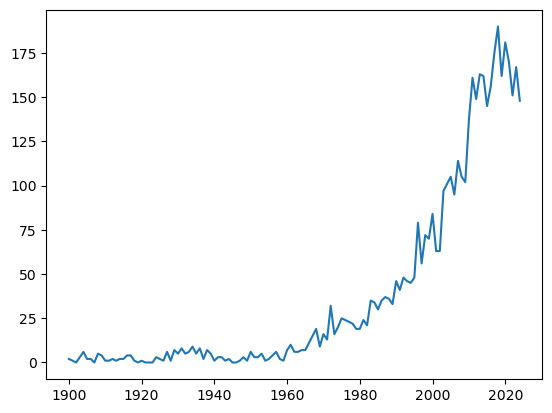

In [ ]:
#growth of graduated students in 14=algebraic geometry
plt.plot(counts.iloc[9])

In [ ]:
#the 9th row is subject=14
codes[9]

np.float64(14.0)

In [29]:
counts_train=counts.iloc[9][:-14].copy()
counts_test=counts.iloc[9][-14:].copy()

In [32]:
simp_exp_smooth = SimpleExpSmoothing(counts_train).fit(smoothing_level=0.5,
                                                                             optimized=False)

/opt/anaconda3/lib/python3.13/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)


/opt/anaconda3/lib/python3.13/site-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
/opt/anaconda3/lib/python3.13/site-packages/statsmodels/tsa/base/tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(


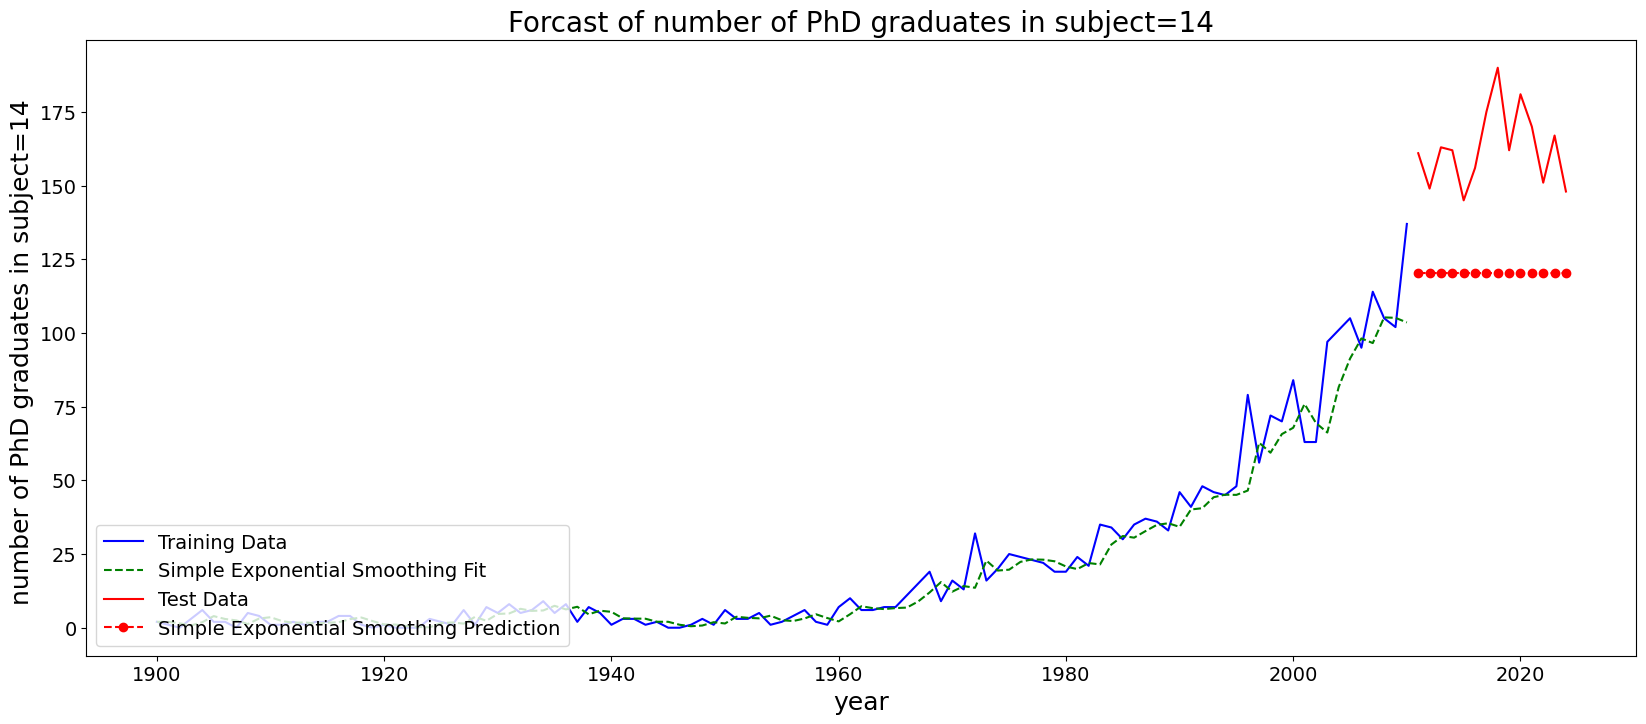

In [45]:
plt.figure(figsize=(20,8))


plt.plot(years[:-14], 
         counts_train,
         'b',
         label="Training Data")


## We can get the fitted values with fittedvalues
plt.plot(years[:-14], 
         simp_exp_smooth.fittedvalues,
         'g--',
         label="Simple Exponential Smoothing Fit")

plt.plot(years[-14:], 
         counts_test[-14:],
         'r',
         label="Test Data")

## We can get the forecast with .forecast(h)
plt.plot(years[-14:], 
         simp_exp_smooth.forecast(14),
         'r--o',
         label="Simple Exponential Smoothing Prediction")

plt.xlabel("year", fontsize=18)
plt.ylabel("number of PhD graduates in subject=14 ", fontsize=18)
plt.title("Forcast of number of PhD graduates in subject=14", fontsize=20)

plt.xticks(fontsize=14)
plt.yticks(fontsize=14)

plt.legend(fontsize=14, loc=3)

plt.show()

### 1.2 Forcast of precentage

In [47]:
share

year,1900,1901,1902,1903,1904,1905,1906,1907,1908,1909,...,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024
subject_code,,,,,,,,,,,,,,,,,,,,,
0.0,0.000000,5.555556,0.0,0.000000,0.00,11.111111,0.0,0.0,0.000000,0.000000,...,1.153999,1.765914,1.326700,1.455133,1.204319,1.285714,1.043557,1.115242,0.752284,0.647059
1.0,7.692308,5.555556,0.0,18.181818,0.00,11.111111,0.0,0.0,4.347826,0.000000,...,0.278552,0.205339,0.165837,0.161681,0.166113,0.047619,0.226860,0.000000,0.000000,0.117647
3.0,0.000000,5.555556,10.0,9.090909,6.25,0.000000,0.0,0.0,8.695652,0.000000,...,3.581377,3.449692,4.684909,4.001617,3.903654,3.476190,3.176044,3.823686,3.492746,4.352941
5.0,0.000000,0.000000,10.0,0.000000,0.00,0.000000,0.0,0.0,0.000000,8.333333,...,8.396339,7.597536,8.167496,9.054163,8.181063,8.047619,8.484574,8.443972,8.113917,8.529412
6.0,0.000000,0.000000,0.0,0.000000,0.00,0.000000,0.0,10.0,0.000000,0.000000,...,0.716275,0.533881,0.414594,0.687146,0.332226,0.428571,0.453721,0.265534,0.161204,0.588235
8.0,0.000000,0.000000,0.0,0.000000,0.00,0.000000,0.0,0.0,0.000000,0.000000,...,0.397931,0.369610,0.414594,0.242522,0.415282,0.523810,0.362976,0.265534,0.161204,0.117647
11.0,23.076923,11.111111,10.0,18.181818,0.00,11.111111,20.0,20.0,4.347826,8.333333,...,8.197374,8.624230,8.043118,8.811641,8.887043,8.619048,8.892922,9.665428,8.919936,8.411765
12.0,7.692308,0.000000,0.0,0.000000,0.00,0.000000,0.0,0.0,0.000000,0.000000,...,0.358138,0.164271,0.165837,0.080841,0.207641,0.333333,0.181488,0.477961,0.161204,0.411765
13.0,0.000000,0.000000,0.0,0.000000,0.00,0.000000,0.0,0.0,0.000000,0.000000,...,2.268205,1.601643,1.948590,2.101859,1.910299,2.333333,1.905626,2.177377,1.880709,1.941176


In [ ]:
#precentage of subject=14 train-test-split
share_train=share.iloc[9][:-14].copy()
share_test=share.iloc[9][-14:].copy()

In [49]:
simp_exp_smooth = SimpleExpSmoothing(share_train).fit(smoothing_level=0.5,
                                                                             optimized=False)

/opt/anaconda3/lib/python3.13/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)


/opt/anaconda3/lib/python3.13/site-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
/opt/anaconda3/lib/python3.13/site-packages/statsmodels/tsa/base/tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(


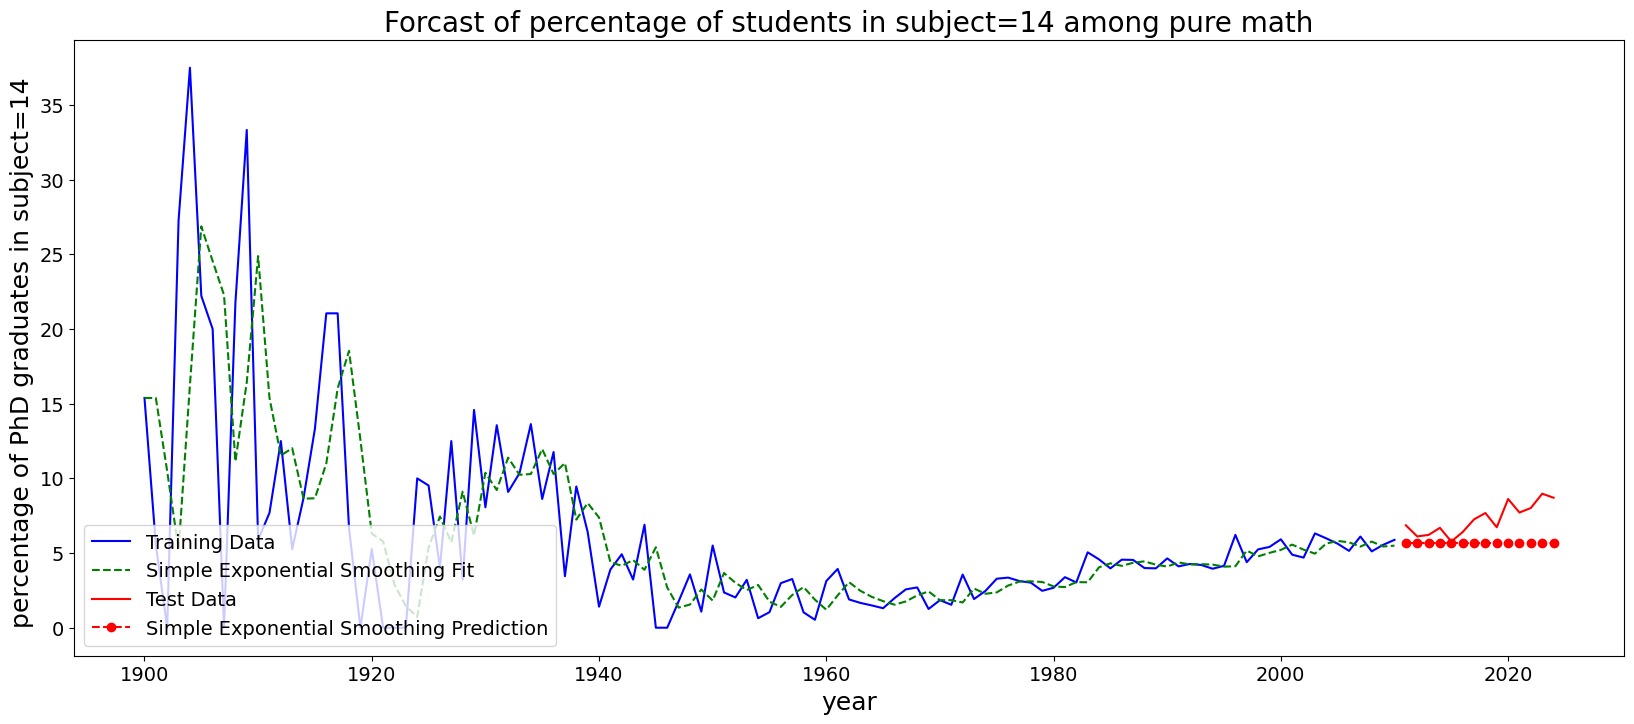

In [50]:
plt.figure(figsize=(20,8))


plt.plot(years[:-14], 
         share_train,
         'b',
         label="Training Data")


## We can get the fitted values with fittedvalues
plt.plot(years[:-14], 
         simp_exp_smooth.fittedvalues,
         'g--',
         label="Simple Exponential Smoothing Fit")

plt.plot(years[-14:], 
         share_test[-14:],
         'r',
         label="Test Data")

## We can get the forecast with .forecast(h)
plt.plot(years[-14:], 
         simp_exp_smooth.forecast(14),
         'r--o',
         label="Simple Exponential Smoothing Prediction")

plt.xlabel("year", fontsize=18)
plt.ylabel("percentage of PhD graduates in subject=14 ", fontsize=18)
plt.title("Forcast of percentage of students in subject=14 among pure math", fontsize=20)

plt.xticks(fontsize=14)
plt.yticks(fontsize=14)

plt.legend(fontsize=14, loc=3)

plt.show()

Looks like percentage predict is more unbiased.

## To do: 
## 1. Exponential smoothing for other subjects
## 2. kfold validation
## 3. compare other prediction models on mse